# Customer Churn Prediction

This notebook demonstrates the complete workflow:

Business Problem → Data → Preparation → EDA → Feature Engineering →
Model → Evaluation → Interpretation → Saved Model → API-ready Pipeline

In [160]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# This allows the notebook to import code from the project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from features.build_features import ChurnFeatureEngineer


RANDOM_STATE = 42

DATA_PATH = PROJECT_ROOT / "data" / "TelcoCustomerChurn.csv"
MODEL_DIR = PROJECT_ROOT / "model"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Business Problem

A telecommunications company wants to identify customers who are likely to churn.
If high-risk customers can be identified early, the retention team can contact
them with offers, support, or better plans before they leave.

This is a binary classification problem:

- Input: customer demographics, services, contract, tenure, and billing data
- Target: `Churn`
- Target values: `Yes` or `No`

## 2. Data Loading and Understanding

In [161]:
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [162]:
df.shape

(7043, 21)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [164]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [166]:
print("Missing values before cleaning:")
df.isna().sum()

Missing values before cleaning:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [167]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [168]:
print("Target distribution:")
df["Churn"].value_counts()

Target distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [169]:
print("Target distribution percentage:")
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Target distribution percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [170]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### Important Data Observation

`TotalCharges` should be numeric, but in the original IBM Telco dataset it can
contain blank strings. Therefore, it needs to be converted using
`pd.to_numeric(..., errors="coerce")`.

`customerID` is only an identifier. It should not be used as a model feature
because it does not describe customer behaviour and could encourage memorization.

In [171]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
df.isna().sum()

Missing values after converting TotalCharges:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [172]:
# Drop customerID before modelling.
# This is important because customerID is an identifier, not a predictive feature.
# Dropping it also helps prevent ID-based memorization.
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploratory Data Analysis

The purpose of EDA is to understand customer behaviour and identify patterns
associated with churn.

In [173]:
sns.set_theme(style="whitegrid")

### Visualization 1: Churn Distribution

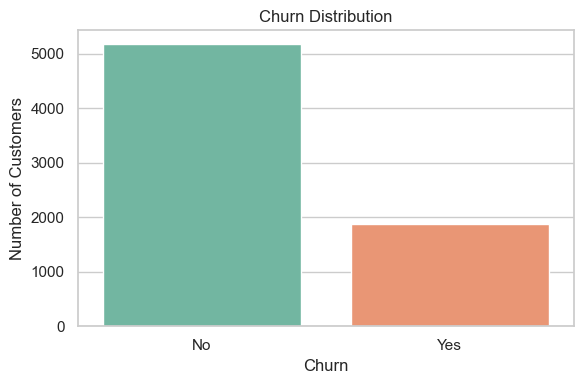

In [174]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="Set2",
    legend=False,
)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business insight:** Most customers do not churn, but the churn group is still
large enough to represent a meaningful retention opportunity.

### Visualization 2: Churn by Contract Type

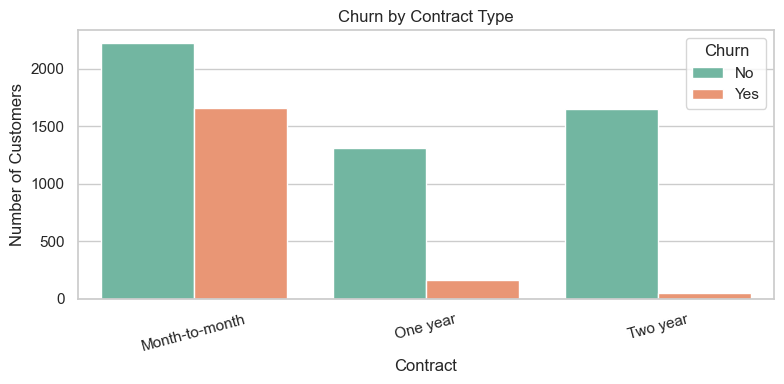

In [175]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2",
)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Business insight:** Month-to-month customers usually show higher churn risk.
Longer contracts appear to create stronger customer commitment.

### Visualization 3: Churn by Internet Service

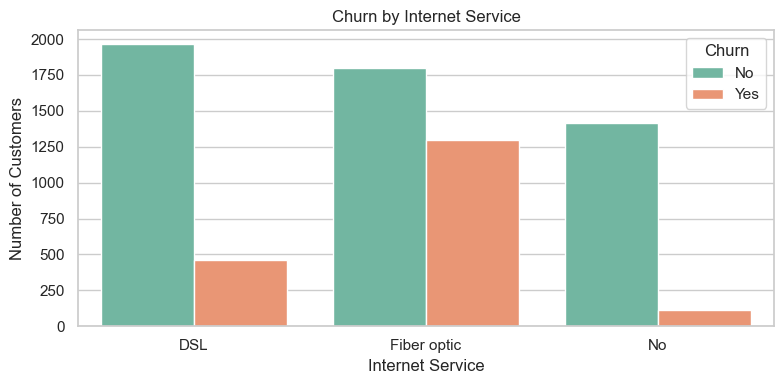

In [176]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set2",
)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business insight:** Churn differs across internet service categories. This
may indicate differences in price, service quality, or customer expectations.

### Visualization 4: Monthly Charges by Churn

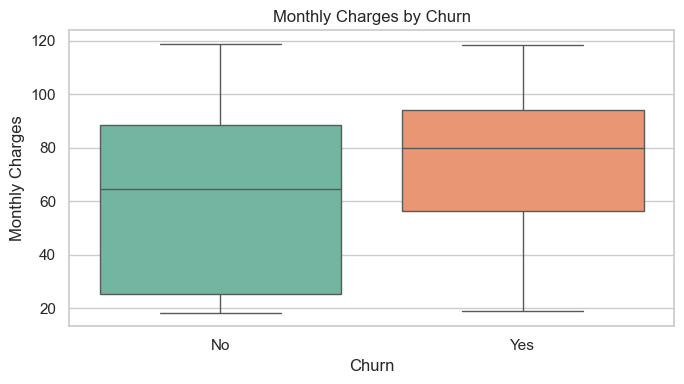

In [177]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False,
)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

**Business insight:** Customers who churn often have higher monthly charges,
suggesting that pricing or value perception may influence churn.

### Visualization 5: Tenure Distribution by Churn

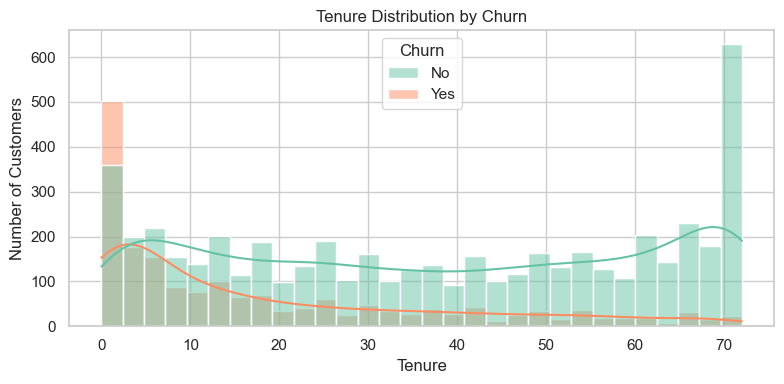

In [178]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30,
    palette="Set2",
)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business insight:** Customers with shorter tenure are more likely to churn.
This suggests that onboarding and early engagement are important.

### Visualization 6: Churn by Payment Method

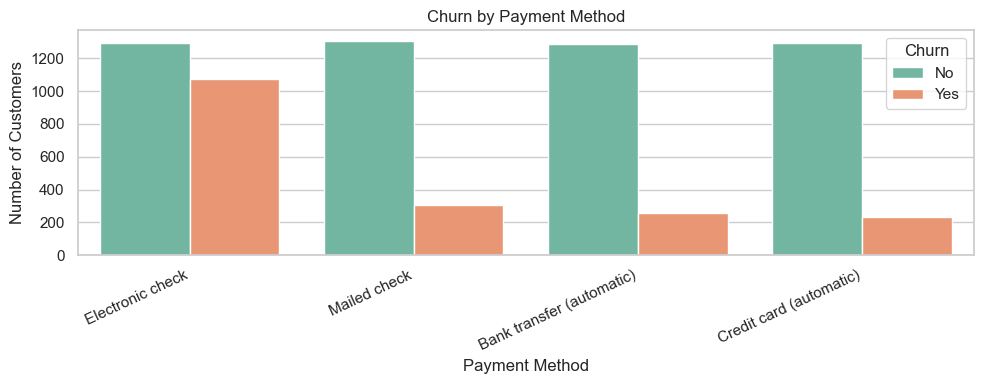

In [179]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2",
)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Business insight:** Some payment methods are associated with higher churn.
This could reflect billing friction or differences in customer segments.

## 4. Feature Engineering

Feature engineering code is kept in:

`features/build_features.py`

The feature engineering is placed inside a sklearn-compatible transformer so
the same logic is used during model training and API prediction.

In [180]:
feature_engineer = ChurnFeatureEngineer()
engineered_preview = feature_engineer.fit_transform(df.drop(columns=["Churn"]))
engineered_preview.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,avg_charge_per_tenure_month,is_month_to_month,has_security_and_support,has_streaming_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0-12 months,29.850000,Yes,No,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,25-48 months,55.573529,No,No,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,0-12 months,54.075000,Yes,No,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,25-48 months,40.905556,No,Yes,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,0-12 months,75.825000,Yes,No,No


### Engineered Features

1. `tenure_group`
   - Created by grouping `tenure` into lifecycle bands.
   - Useful because new customers and long-term customers often churn differently.

2. `avg_charge_per_tenure_month`
   - Created as `TotalCharges / tenure`.
   - Useful because it captures approximate billing intensity over the customer lifetime.

3. `is_month_to_month`
   - Created from the `Contract` column.
   - Useful because month-to-month customers have less commitment.

4. `has_security_and_support`
   - Created from `OnlineSecurity` and `TechSupport`.
   - Useful because support and security services may indicate stronger engagement.

5. `has_streaming_services`
   - Created from `StreamingTV` and `StreamingMovies`.
   - Useful because bundled services may increase customer stickiness.

## 5. Data Preparation for Modelling

The data is split into 70% training and 30% testing.

The test data is not used during preprocessing fitting or hyperparameter tuning.
This helps avoid data leakage.

In [181]:
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

# Safety check: customerID should already be removed, but this ensures it is not
# used even if the previous cell is edited later.
X = X.drop(columns=["customerID"], errors="ignore")

if y.isna().any():
    raise ValueError("The Churn column contains values other than 'Yes' and 'No'.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training shape: (4930, 19)
Testing shape: (2113, 19)

Training target distribution:
Churn
0    0.7347
1    0.2653
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.7345
1    0.2655
Name: proportion, dtype: float64


In [182]:
def build_pipeline(classifier):
    """
    Build a complete feature engineering, preprocessing, and modelling pipeline.

    Keeping everything inside one pipeline ensures that training data, test data,
    and future API data receive the same transformations.
    """

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                make_column_selector(dtype_include=["int64", "float64"]),
            ),
            (
                "cat",
                categorical_pipeline,
                make_column_selector(dtype_include=["object", "category", "bool"]),
            ),
        ]
    )

    return Pipeline(
        steps=[
            ("feature_engineering", ChurnFeatureEngineer()),
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )


def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics required by the assignment."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }

## 6. Model Development

The assignment requires a Decision Tree Classifier. Two baseline Decision Tree
configurations are trained first, then hyperparameter tuning is performed using
GridSearchCV.

### 6.1 Baseline Decision Tree Models

In [183]:
baseline_configs = {
    "Decision Tree - depth 4": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=25,
        random_state=RANDOM_STATE,
    ),
    "Decision Tree - depth 6 balanced": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

baseline_results = []
trained_baseline_models = {}

for model_name, classifier in baseline_configs.items():
    pipeline = build_pipeline(classifier)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    metrics = calculate_metrics(y_test, y_pred)

    baseline_results.append(
        {
            "model": model_name,
            **metrics,
        }
    )

    trained_baseline_models[model_name] = pipeline

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree - depth 4,0.791765,0.657963,0.449198,0.533898
1,Decision Tree - depth 6 balanced,0.736867,0.502825,0.793226,0.615491


### 6.2 Hyperparameter Tuning

Hyperparameter tuning systematically searches for better Decision Tree settings.

Tuned hyperparameters:

- `criterion`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `class_weight`

`GridSearchCV` uses 5-fold stratified cross-validation.

The scoring metric is F1 score because it balances precision and recall.
Recall is especially important for churn because missing a real churner can
mean losing the customer without any retention attempt.

In [184]:
tuning_pipeline = build_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE)
)

parameter_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 4, 5, 6, 8, None],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [5, 10, 20, 30],
    "classifier__class_weight": [None, "balanced"],
}

cross_validator = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=parameter_grid,
    scoring="f1",
    cv=cross_validator,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


/Users/ankit/Desktop/nagp-assignment/customer_churn_project/.venv312/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_engineering',
                                        ChurnFeatureEngineer()),
                                       ('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x12828f980>),
                                                                        ('cat',...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x1287cc7d0>)])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 4, 5, 6, 8, None],
                         'classifier__min_samples_leaf': [5, 10, 20, 30],
                         'classifier__min_samples_split': [2, 10, 20]},
             scoring='f1', verbose=1)

In [185]:
print("Best Decision Tree hyperparameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    "\nBest mean cross-validation F1 score:",
    round(grid_search.best_score_, 4),
)

Best Decision Tree hyperparameters:
classifier__class_weight: balanced
classifier__criterion: gini
classifier__max_depth: 4
classifier__min_samples_leaf: 5
classifier__min_samples_split: 2

Best mean cross-validation F1 score: 0.6107


In [186]:
tuning_results_df = pd.DataFrame(grid_search.cv_results_)

tuning_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_classifier__criterion",
    "param_classifier__max_depth",
    "param_classifier__min_samples_split",
    "param_classifier__min_samples_leaf",
    "param_classifier__class_weight",
]

top_tuning_results = (
    tuning_results_df[tuning_columns]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

top_tuning_results

,rank_test_score,mean_test_score,std_test_score,param_classifier__criterion,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__class_weight
0,1,0.610662,0.022060,gini,4,20,5,balanced
1,1,0.610662,0.022060,gini,4,2,5,balanced
2,1,0.610662,0.022060,gini,4,10,5,balanced
3,4,0.610486,0.022245,gini,4,2,10,balanced
4,4,0.610486,0.022245,gini,4,10,10,balanced
5,4,0.610486,0.022245,gini,4,20,10,balanced
6,7,0.610280,0.022467,gini,4,10,20,balanced
7,7,0.610280,0.022467,gini,4,2,20,balanced
8,7,0.610280,0.022467,gini,4,2,30,balanced
9,7,0.610280,0.022467,gini,4,10,30,balanced


In [187]:
tuning_results_df[tuning_columns].sort_values("rank_test_score").to_csv(
    OUTPUT_DIR / "hyperparameter_tuning_results.csv",
    index=False,
)

print(
    "Saved hyperparameter tuning results to:",
    OUTPUT_DIR / "hyperparameter_tuning_results.csv",
)

Saved hyperparameter tuning results to: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/outputs/hyperparameter_tuning_results.csv


## 7. Final Model Evaluation

`GridSearchCV` refits the best pipeline using the full training set.
The final tuned model is then evaluated once on the untouched 30% test set.

In [188]:
final_model = grid_search.best_estimator_
final_model_name = "Tuned Decision Tree"

final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

final_metrics = calculate_metrics(y_test, final_predictions)
final_metrics

{'accuracy': 0.7486985328916232,
 'precision': 0.5182926829268293,
 'recall': 0.7575757575757576,
 'f1_score': 0.6154960173787111}

In [189]:
tuned_result = {
    "model": final_model_name,
    **final_metrics,
}

all_results_df = pd.concat(
    [
        baseline_results_df,
        pd.DataFrame([tuned_result]),
    ],
    ignore_index=True,
)

all_results_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree - depth 4,0.791765,0.657963,0.449198,0.533898
1,Decision Tree - depth 6 balanced,0.736867,0.502825,0.793226,0.615491
2,Tuned Decision Tree,0.748699,0.518293,0.757576,0.615496


In [190]:
all_results_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False,
)

print("Saved model comparison to:", OUTPUT_DIR / "model_comparison.csv")

Saved model comparison to: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/outputs/model_comparison.csv


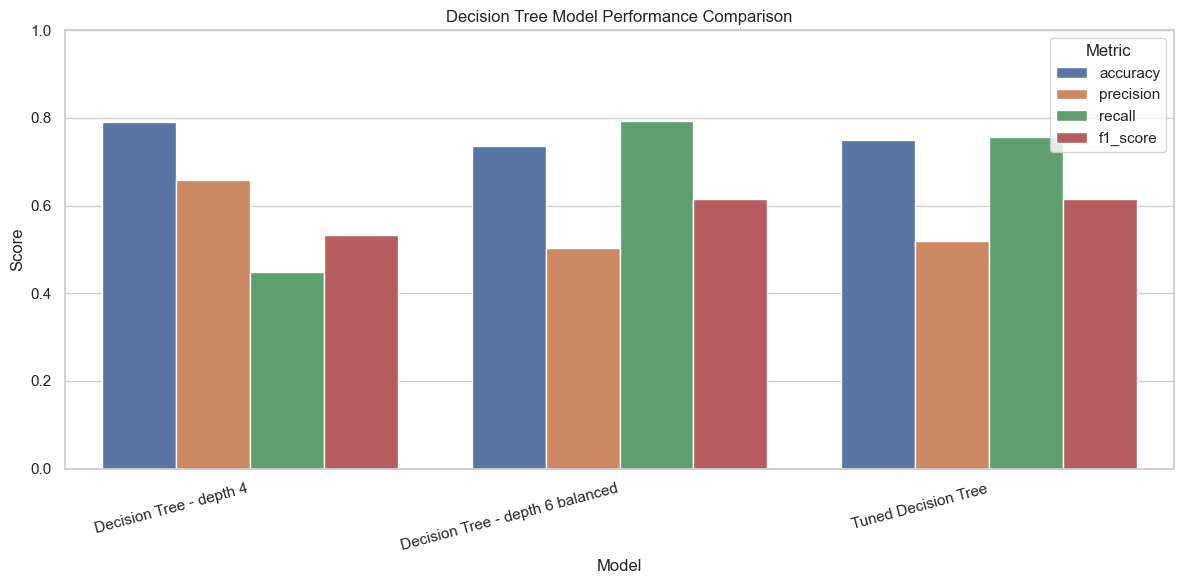

In [191]:
comparison_plot = all_results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_plot,
    x="model",
    y="score",
    hue="metric",
)
plt.title("Decision Tree Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

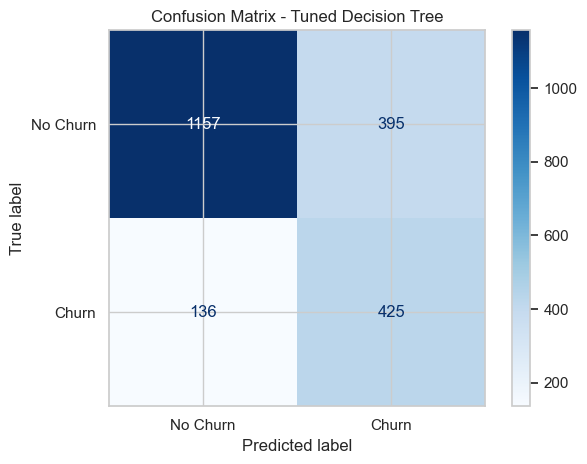

In [192]:
confusion = confusion_matrix(y_test, final_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["No Churn", "Churn"],
)

display.plot(
    cmap="Blues",
    values_format="d",
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [193]:
print("Final model metrics:")
print("Accuracy:", round(final_metrics["accuracy"], 4))
print("Precision:", round(final_metrics["precision"], 4))
print("Recall:", round(final_metrics["recall"], 4))
print("F1 Score:", round(final_metrics["f1_score"], 4))

Final model metrics:
Accuracy: 0.7487
Precision: 0.5183
Recall: 0.7576
F1 Score: 0.6155


### Business Interpretation

- **Accuracy** shows the overall percentage of correct predictions.
- **Precision** tells us how many predicted churners actually churned.
- **Recall** tells us how many actual churners were identified.
- **F1 score** balances precision and recall.

For telecom churn prediction, recall is usually prioritized because missing a
true churner means the retention team may not contact that customer before they
leave. False positives are less costly because the business may simply contact
an extra customer.

## 8. Model Interpretation

Decision Trees can be interpreted using feature importance and tree structure.

In [194]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importance_values = classifier.feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importance_values,
    }
).sort_values(
    "importance",
    ascending=False,
)

importance_df.head(15)

,feature,importance
51,cat__is_month_to_month_Yes,0.653438
1,num__tenure,0.113895
17,cat__InternetService_Fiber optic,0.108821
2,num__MonthlyCharges,0.038365
19,cat__OnlineSecurity_No,0.019917
18,cat__InternetService_No,0.017697
28,cat__TechSupport_No,0.015850
44,cat__PaymentMethod_Electronic check,0.015369
38,cat__Contract_One year,0.006365
3,num__TotalCharges,0.005831


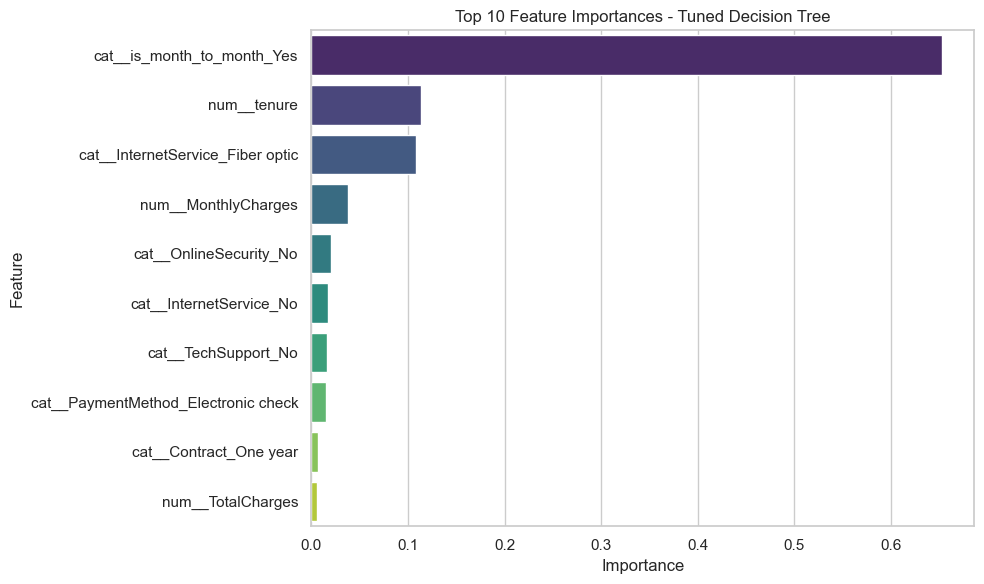

In [195]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    y="feature",
    x="importance",
    hue="feature",
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Feature Importances - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

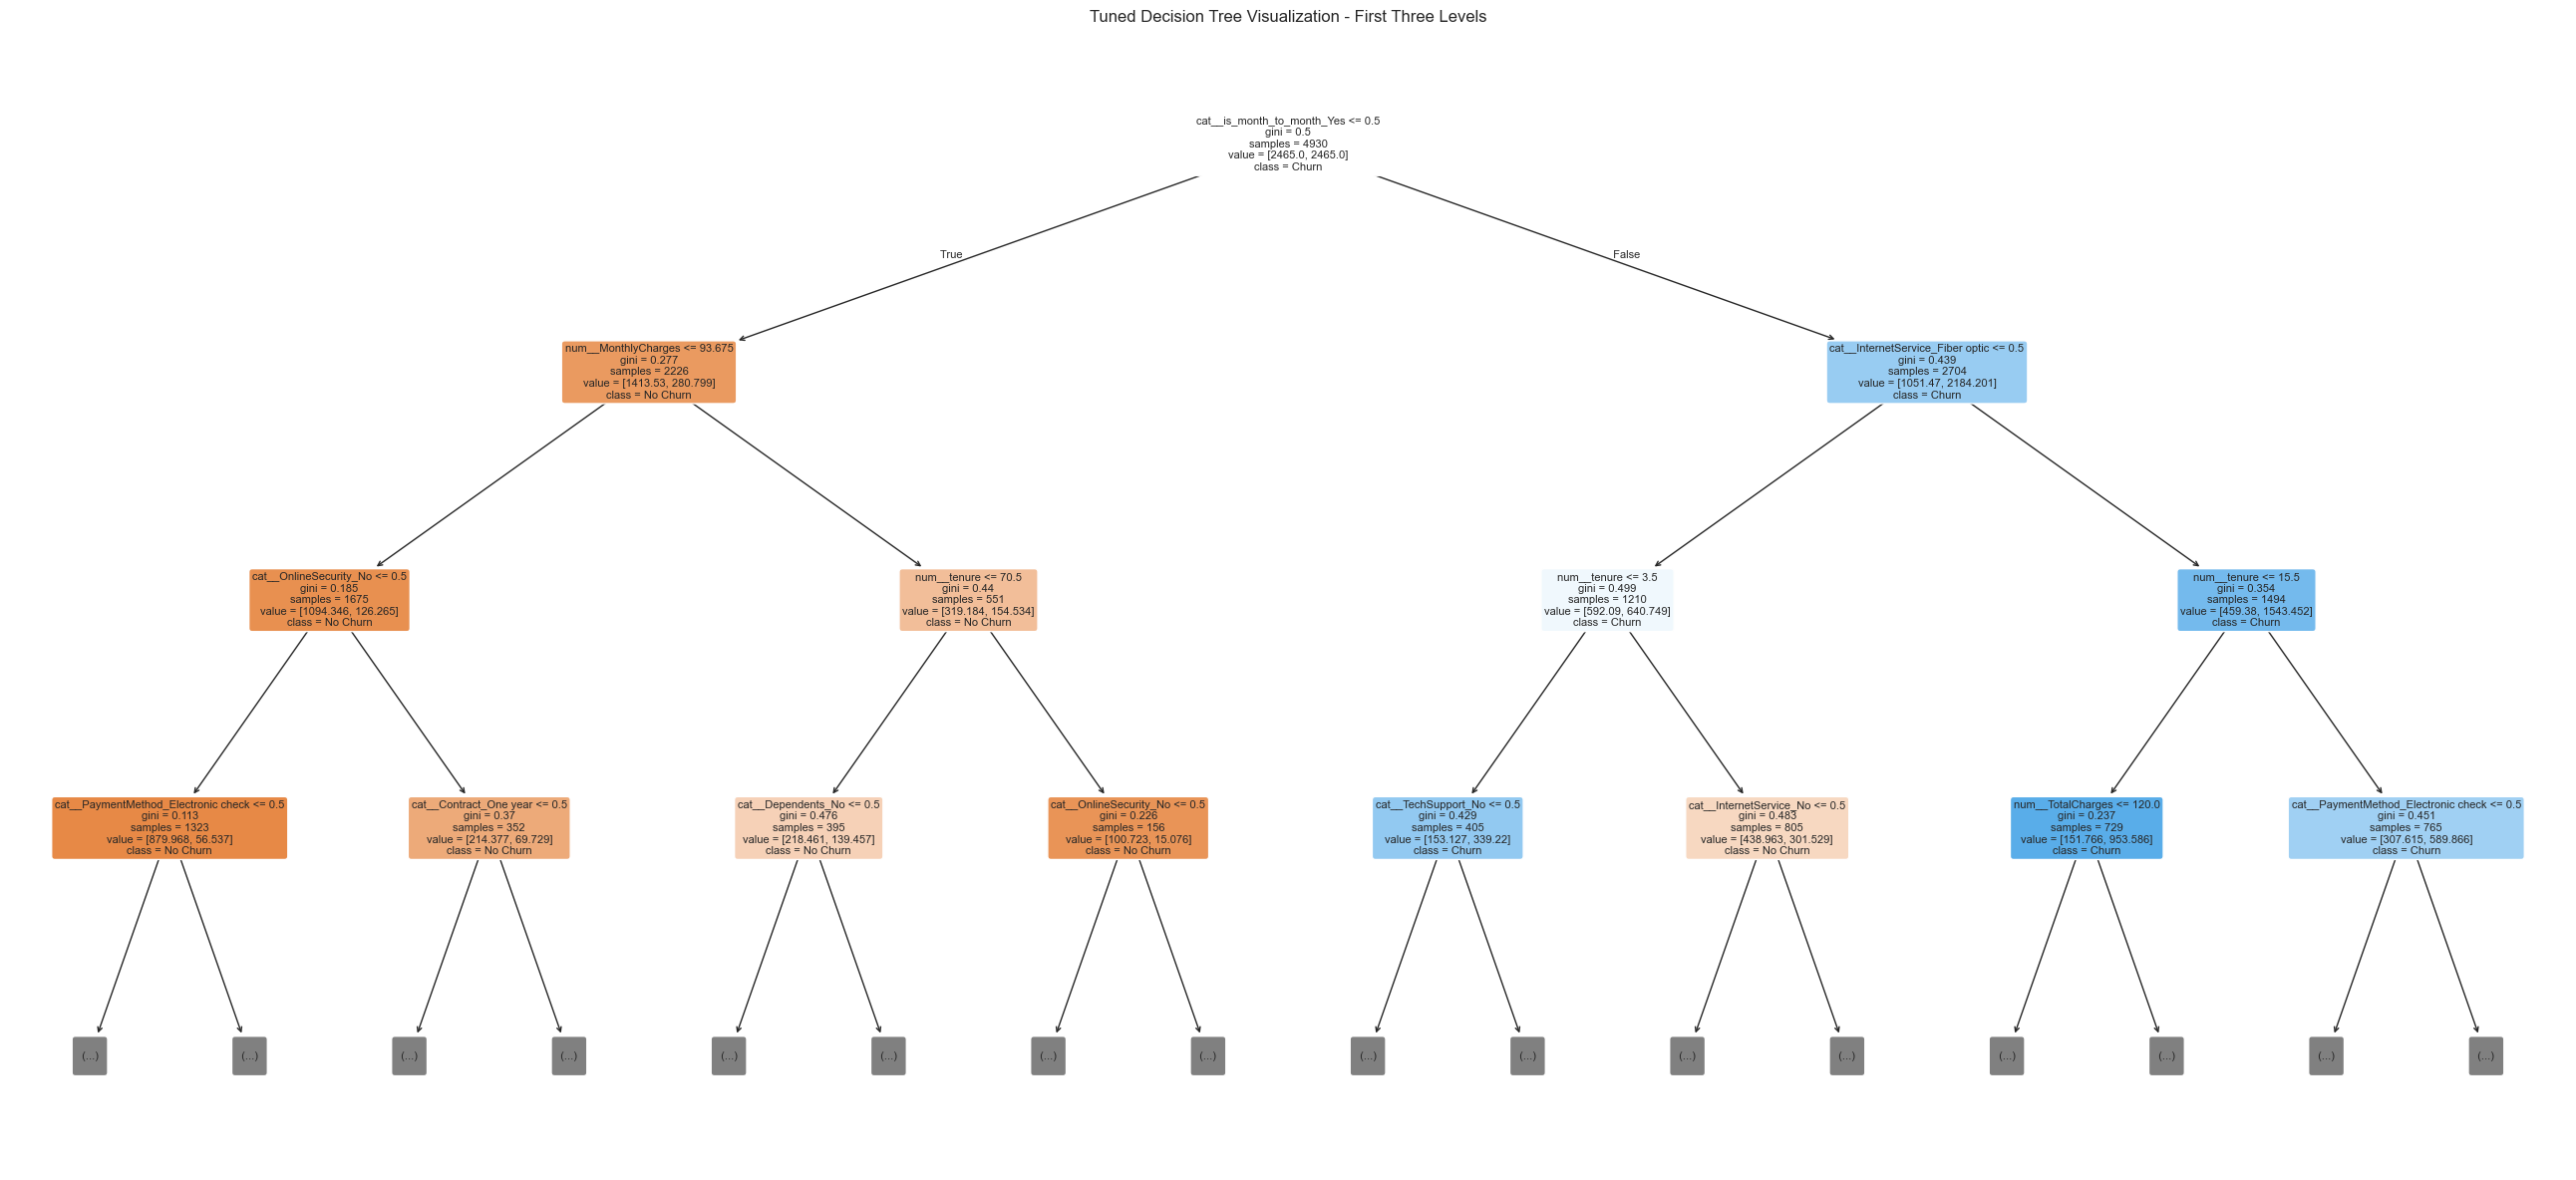

In [196]:
plt.figure(figsize=(26, 12))
plot_tree(
    classifier,
    max_depth=3,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Tuned Decision Tree Visualization - First Three Levels")
plt.tight_layout()
plt.show()

### Key Interpretation

The strongest churn drivers are usually related to contract type, tenure,
monthly charges, internet service, support services, and payment method.

These features are meaningful from a business perspective because they reflect:

- customer commitment
- service usage
- price sensitivity
- support experience
- customer lifecycle stage

## 9. Save the Final Pipeline

The complete pipeline is saved rather than only the Decision Tree.

The saved pipeline includes:

- feature engineering
- missing-value handling
- categorical encoding
- fitted Decision Tree model

This makes the pipeline reusable for API prediction.

In [197]:
model_path = MODEL_DIR / "churn_model.pkl"
joblib.dump(final_model, model_path)

serializable_metrics = {
    metric_name: float(metric_value)
    for metric_name, metric_value in final_metrics.items()
}

metadata = {
    "model_name": final_model_name,
    "random_state": RANDOM_STATE,
    "test_size": 0.30,
    "target_mapping": {
        "No": 0,
        "Yes": 1,
    },
    # customerID is intentionally excluded because it was dropped before modelling.
    # The API should not require customerID for prediction.
    "required_columns": [
        column for column in X.columns
        if column != "customerID"
    ],
    "metrics": serializable_metrics,
    "hyperparameter_tuning": {
        "enabled": True,
        "method": "GridSearchCV",
        "scoring": "f1",
        "cross_validation": "5-fold StratifiedKFold",
        "best_cross_validation_f1": float(grid_search.best_score_),
        "best_parameters": grid_search.best_params_,
    },
    "class_imbalance_handling": (
        "GridSearchCV compared class_weight=None with "
        "class_weight='balanced'."
    ),
    "business_priority": (
        "Recall is important because missing a genuine churner may cause the "
        "company to lose the customer without attempting retention."
    ),
}

metadata_path = MODEL_DIR / "model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=4,
        default=str,
    )

importance_df.to_csv(
    OUTPUT_DIR / "feature_importance.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "final_model_metrics.json",
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        serializable_metrics,
        metrics_file,
        indent=4,
    )

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved feature importance:", OUTPUT_DIR / "feature_importance.csv")
print("Saved final metrics:", OUTPUT_DIR / "final_model_metrics.json")

Saved model: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/model/churn_model.pkl
Saved metadata: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/model/model_metadata.json
Saved feature importance: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/outputs/feature_importance.csv
Saved final metrics: /Users/ankit/Desktop/nagp-assignment/customer_churn_project/outputs/final_model_metrics.json


## 10. API Usage

The saved model can be loaded by the FastAPI application in `app.py`.

The API endpoint is:

`POST /predict`

It accepts a customer JSON object, applies the saved preprocessing pipeline,
and returns:

- churn prediction
- churn probability

Example API response:

```json
{
  "prediction": "Yes",
  "churn_probability": 0.82
}
```

## 11. Final Business Conclusion

This project built an end-to-end churn prediction workflow:

Business Problem → Data → Preparation → EDA → Feature Engineering →
Model → Evaluation → Interpretation → Saved Model → API-ready Pipeline

The tuned Decision Tree model provides a practical churn-risk screening tool.
For a telecom company, recall is especially important because the business
wants to identify as many likely churners as possible before they leave.

Although false positives may create extra retention contacts, missing true
churners can be more costly because those customers may be lost permanently.